# Bathymetry and Boundaries for AMR-Wind from FVCOM

In [108]:
# Load modules.

import numpy as np
#import pandas as pd
#import sys, math  
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
#import os, glob, shutil
#import subprocess
#import time
import netCDF4 as nc
import xarray as xr
import scipy as sc
import shapefile as shpfl
import inflowPrepMMC as mmc
import terrain as terrain
import amrex.space3d as amr              # from pyamrex, which is required to use Marc's library below
import native_boundary_plane as nbp      # Marc's boundary data manipulation library
import boundaryDataFunctors              # Matt's own library of functors necessary to work with Marc's AMReX boundary data writer.

from scipy.interpolate import LinearNDInterpolator   # Because we're interpolating from FVCOM data to AMR-Wind
from scipy.interpolate import NearestNDInterpolator  # Because we're interpolating from FVCOM data to AMR-Wind


plt.rcParams['axes.grid'] = True
plt.rcParams['figure.autolayout'] = True





In [2]:
### User input.

# Path to both the raw and reduced FVCOM data.
rawPath = '/projects/hfm/churchfield/rosario/FVCOM/WA_puget_sound/v1.0.0/00_raw/Puget_Sound_corrected/02012015/'
reducedPath = '/projects/hfm/churchfield/rosario/FVCOM/WA_puget_sound/v1.0.0/00_raw/Puget_Sound_corrected/02012015/reduced/'

# UTM coordinate extents to sample from.
UTMxLo = 514000.0
UTMxHi = 521000.0
UTMyLo = 5.375e6
UTMyHi = 5.3815e6

# Path to location to save SRTM elevation data for land around Rosario Strait.
srtmDataPath = '/projects/hfm/churchfield/estuary_hfm_mmsei/tools/FVCOM-dataExtraction/rosario.tif'

#UTM Zone of Rosario Strait
UTMzone = '10 U'

# Coordinates that AMR-Wind x,y,z lo/hi correspond to
xyzLoUTM = [515000.0, 5376500.0,    0.0]
xyzHiUTM = [521000.0, 5381000.0,  100.0]

# To reduce interpolation time, select a region of this thickness (m) about the boundary plane
interpDataThickness = 200.0





In [141]:
# Rather than load all the FVCOM data, which is slow, Will loaded and then saved some of the data in 
# numpy format.  That's what gets loaded here.  Still one NetCDF file gets loaded just to get some basic
# location information.


ds = xr.open_dataset(rawPath+'psm_0001.nc',decode_times=False)
UTMbounds = np.array([[UTMyLo,UTMyHi],[UTMxLo,UTMxHi]])
UTMcoords = np.where(np.array(ds.yc.values > np.min(UTMbounds[0])) \
                   & np.array(ds.yc.values < np.max(UTMbounds[0])) \
                   & np.array(ds.xc.values > np.min(UTMbounds[1])) \
                   & np.array(ds.xc.values < np.max(UTMbounds[1])))[0]



time = np.load(reducedPath+'PS_time.npy')
xBathymetry = np.load(reducedPath+'PS_x.npy');             # east direction
yBathymetry = np.load(reducedPath+'PS_y.npy');             # north direction
zBathymetry = -np.load(reducedPath+'PS_h.npy');             # depth
nv = np.load(reducedPath+'PS_nv.npy');
siglay = np.load(reducedPath+'PS_siglay.npy');   # normalized depth: sigma = -(z+H)/(zeta+H), where z is height, H is bottom depth, and zeta is sea surface elevation.
u = np.load(reducedPath+'PS_u.npy');             # east velocity
v = np.load(reducedPath+'PS_v.npy');             # north velocity
zeta_node = np.load(reducedPath+'PS_zeta.npy');
zeta = np.zeros((len(time),len(x)))
for t in range(zeta.shape[0]):
    zeta[t,:] = np.mean(zeta_node[t,nv])



    

In [5]:
### Get terrain data for above water part from Shuttle Radar Topography Mission (SRTM) dataset.


# Use the tools in inflowPrepMMC to convert from the UTM bounds of the FVCOM data to latitude/longitude
coords = mmc.inflowPrepMMC()
latLo,lonLo = coords.UTMtoLatLon(np.min(x),np.min(y),UTMzone)
latHi,lonHi = coords.UTMtoLatLon(np.max(x),np.max(y),UTMzone)

# Set up the SRTM data handler.
srtmBounds = (lonLo, latLo, lonHi, latHi)
srtm = terrain.SRTM(srtmBounds, fpath=srtmDataPath, product='SRTM1')

# Download the data as a geotiff.
srtm.download()

# Convert the geotiff data to useable x, y, z data
xTerrain,yTerrain,zTerrain = srtm.to_terrain()
xTerrain = xTerrain.flatten()
yTerrain = yTerrain.flatten()
zTerrain = zTerrain.flatten()





make: Entering directory '/home/mchurchf/.cache/elevation/SRTM1'
make: Nothing to be done for 'download'.
make: Leaving directory '/home/mchurchf/.cache/elevation/SRTM1'
make: Entering directory '/home/mchurchf/.cache/elevation/SRTM1'
make: Nothing to be done for 'all'.
make: Leaving directory '/home/mchurchf/.cache/elevation/SRTM1'
make: Entering directory '/home/mchurchf/.cache/elevation/SRTM1'
cp SRTM1.vrt SRTM1.2c825be7e9774ff6ae2911e57bc33e90.vrt
make: Leaving directory '/home/mchurchf/.cache/elevation/SRTM1'
make: Entering directory '/home/mchurchf/.cache/elevation/SRTM1'
gdal_translate -q -co TILED=YES -co COMPRESS=DEFLATE -co ZLEVEL=9 -co PREDICTOR=2 -projwin -122.86031 48.636227 -122.6653 48.477966 SRTM1.2c825be7e9774ff6ae2911e57bc33e90.vrt /projects/hfm/churchfield/estuary_hfm_mmsei/tools/FVCOM-dataExtraction/rosario.tif
rm -f SRTM1.2c825be7e9774ff6ae2911e57bc33e90.vrt
make: Leaving directory '/home/mchurchf/.cache/elevation/SRTM1'
make: Entering directory '/home/mchurchf/.ca

(5370000.0, 5387500.0)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


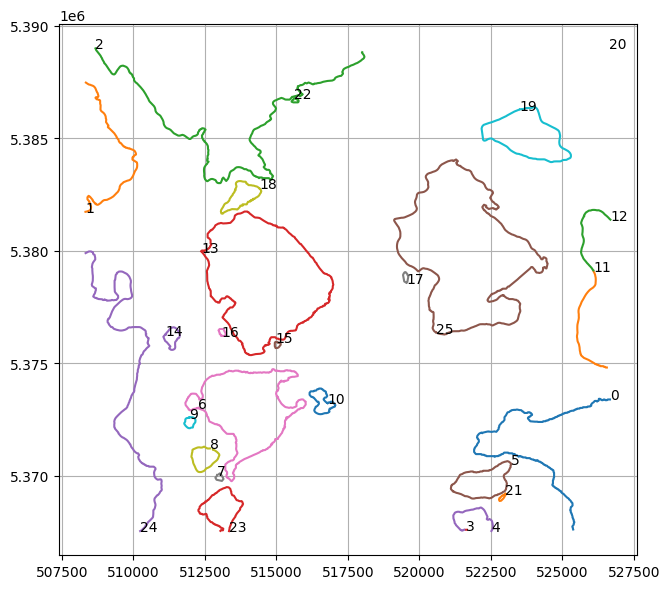

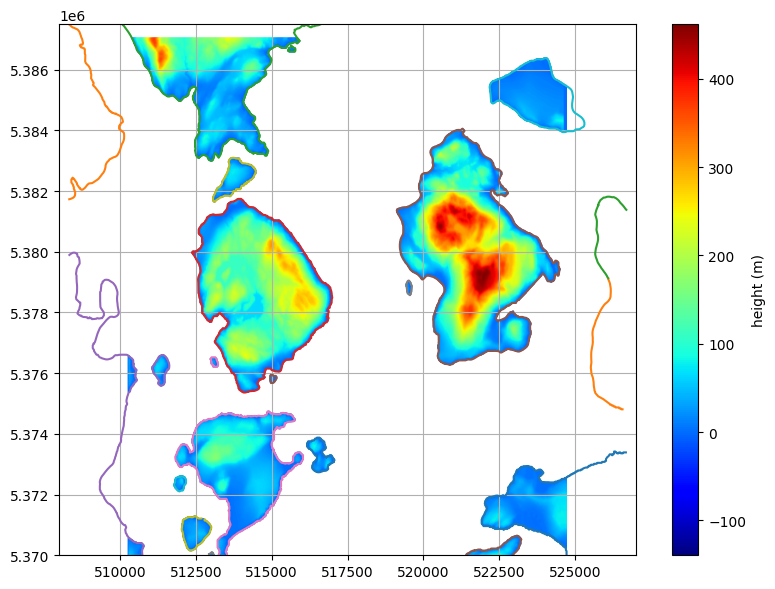

In [157]:
### Get coastal location data from SRTM Water Body Data set.

# I downloaded the data around Rosario Strait from https://earthexplorer.usgs.gov/.  The file is a ESRI shapefile.  It contains
# distinct sets of points for different bodies of water.  Most are lakes and rivers, but set 45 is the Pacific, which outlines the
# islands that create Rosario Strait.

# Read in the shape file using pyshp.
sf = shpfl.Reader('/projects/hfm/churchfield/estuary_hfm_mmsei/tools/FVCOM-dataExtraction/w123n48n.shp')

# Extract the Pacific coastline data.  The data is in lat/lon, so convert to UTM.
waterBody = np.array(sf.shape(45).points)
xWaterBody,yWaterBody,dd = coords.LatLonToUTM(waterBody[:,1],waterBody[:,0],UTMzone)

# The downloaded water body data covers a large geographic extent, so this part cuts it down to a smaller region more
# focused on the region of interest.
maskWBData = True
xBuffer = 2000.0
yBuffer = 2000.0
if (maskWBData):
    mask = np.where(xWaterBody > np.min(xTerrain)-xBuffer)
    xWaterBody = xWaterBody[mask]
    yWaterBody = yWaterBody[mask]
    
    mask = np.where(xWaterBody < np.max(xTerrain)+xBuffer)
    xWaterBody = xWaterBody[mask]
    yWaterBody = yWaterBody[mask]
    
    mask = np.where(yWaterBody > np.min(yTerrain)-yBuffer)
    xWaterBody = xWaterBody[mask]
    yWaterBody = yWaterBody[mask]
    
    mask = np.where(yWaterBody < np.max(yTerrain)+yBuffer)
    xWaterBody = xWaterBody[mask]
    yWaterBody = yWaterBody[mask]


# The Pacific coastline is contained in a single polygon, so it does not distinguish islands from each other.  Look for jumps in distance
# between consecutive points as an indicator of a new island and split to coordinates by island.
xx = []
yy = []
xx_ = []
yy_ = []
jumpDistThreshold = 750.0
for i in range(1,len(xWaterBody)-1):
    ds = np.sqrt(np.square(xWaterBody[i+1] - xWaterBody[i]) + 
                 np.square(yWaterBody[i+1] - yWaterBody[i]))
    if (ds < jumpDistThreshold):
        xx_.append(xWaterBody[i])
        yy_.append(yWaterBody[i])
    else:
        xx.append(np.asarray(xx_))
        yy.append(np.asarray(yy_))
        xx_ = []
        yy_ = []

xIsland = xx
yIsland = yy


# Come up with a terrain elevation map mask to only include data inside the boundaries of islands and disclude anything in the water.
nIsland = len(xIsland)

xyTerrain = np.zeros((len(xTerrain),2))
xyTerrain[:,0] = xTerrain
xyTerrain[:,1] = yTerrain

insideMask = []
for i in range(nIsland):
    xyIsland = np.zeros((len(xIsland[i]),2))
    xyIsland[:,0] = xIsland[i]
    xyIsland[:,1] = yIsland[i]
    path = mpath.Path(xyIsland)
    tf = path.contains_points(xyTerrain)
    for j in range(len(tf)):
        if (tf[j]):
            insideMask.append(j)





plt.figure(0,figsize=(6.8,6))
for i in range(len(xIsland)):
    plt.plot(xIsland[i],yIsland[i])
    plt.text(xIsland[i][0],yIsland[i][0],str(i))


plt.figure(1,figsize=(8,6))
plt.scatter(xTerrain[insideMask],yTerrain[insideMask],c=zTerrain[insideMask],s=0.5,cmap='jet',vmin=np.min(-h),vmax=np.max(zTerrain))
#plt.scatter(xBathymetry,yBathymetry,c=zBathymetry,s=0.5,cmap='jet',vmin=np.min(-h),vmax=np.max(zTerrain))
for i in range(len(xIsland)):
    plt.plot(xIsland[i],yIsland[i])
plt.axis('equal')
plt.colorbar(label='height (m)')
plt.xlim((510000,525000))
plt.ylim((5.37E6,5.3875E6))



In [156]:
### Combine the terrain data and bathymmetry data.
x = np.concatenate((xBathymetry,xTerrain),axis=0)
y = np.concatenate((yBathymetry,yTerrain),axis=0)
z = np.concatenate((zBathymetry,zTerrain),axis=0)





In [30]:
# Find the indices of points that are within 100 m of the point of interest.

deploymentLocation = [5.17500e5,5.3785e6]
distTol = 200.0
deploymentTol = 40.0

# point of interest
inpoint = [518000,5.3765e6]

# compute distance from a plane passing through the point of interest with normal "invec"
invec = [0,1]
dist = np.abs(np.transpose([x - inpoint[0],y - inpoint[1]]) @ invec)

# array of true/false if index is within 100 m.  Later this becomes grid points surrounding the "inlet" if flow is from south to north.
iin = np.array(dist < distTol)

# find roughly the location of deployment
ifast = np.where(((x - deploymentLocation[0])**2 + (y - deploymentLocation[1])**2)**0.5 < deploymentTol)[0][0] 

print('index of deployment location:',ifast)





index of deployment location: 3697


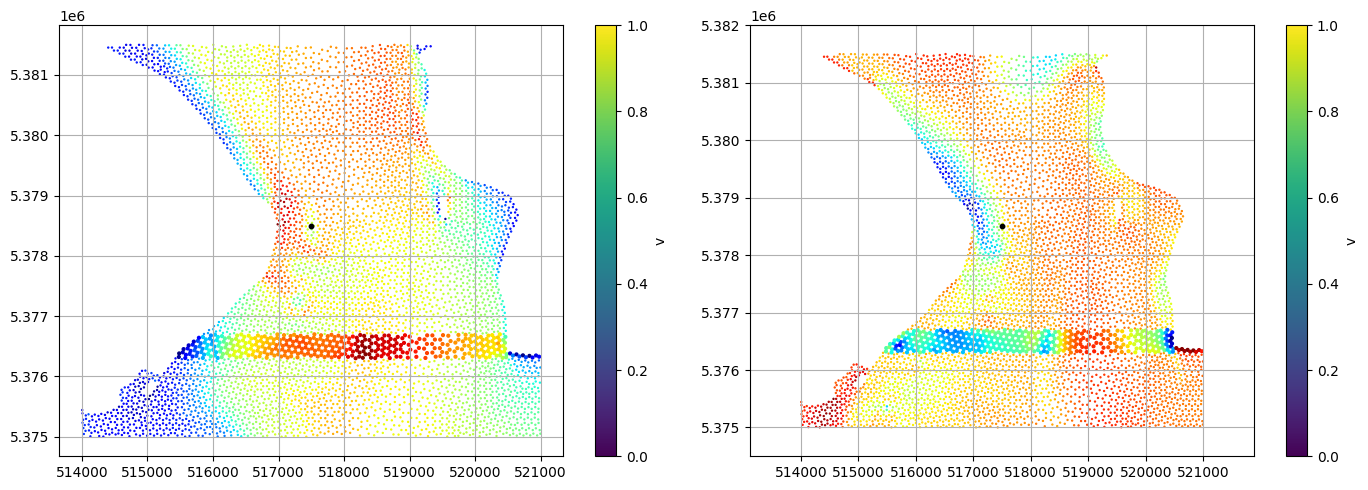

In [31]:
# Plot some of the data.  Choose the field, the time, and the sigma level.

field0 = v
t0 = 0
sig0 = 1

field1 = v
t1 = 10
sig1 = 1

if len(field0.shape) == 3:
    color0 = field0[t0,sig0,:]
    colorin0 = field0[t0,sig0,iin]
elif len(field0.shape) == 2:
    if field0.shape[0] == time0.shape[0]:
        color0 = field0[t0,:]
        colorin0 = field0[t0,iin]
    else:
        color0 = field[sig0,:]
        colorin0 = field[sig0,iin]
elif len(field.shape) == 1:
    color0 = field0
    colorin0 = field0[iin]

if len(field1.shape) == 3:
    color1 = field1[t1,sig1,:]
    colorin1 = field1[t1,sig1,iin]
elif len(field1.shape) == 2:
    if field1.shape[0] == time1.shape[0]:
        color1 = field1[t1,:]
        colorin1 = field1[t1,iin]
    else:
        color1 = field[sig1,:]
        colorin1 = field[sig1,iin]
elif len(field.shape) == 1:
    color1 = field1
    colorin1 = field1[iin]



fig,axs = plt.subplots(1,2,figsize=(14,5))

scat0 = axs[0].scatter(x,y,c=color0,cmap='jet',s=0.5)
scat0 = axs[0].scatter(x[iin],y[iin],c=colorin0,cmap='jet',s=4)
scat0 = axs[0].scatter(deploymentLocation[0],deploymentLocation[1],c='black',s=10)
plt.axis('equal')
plt.colorbar(scat0,label='v')

scat1 = axs[1].scatter(x,y,c=color1,cmap='jet',s=0.5)
scat1 = axs[1].scatter(x[iin],y[iin],c=colorin1,cmap='jet',s=4)
scat1 = axs[1].scatter(deploymentLocation[0],deploymentLocation[1],c='black',s=10)
plt.axis('equal')
plt.colorbar(scat1,label='v')

plt.show()





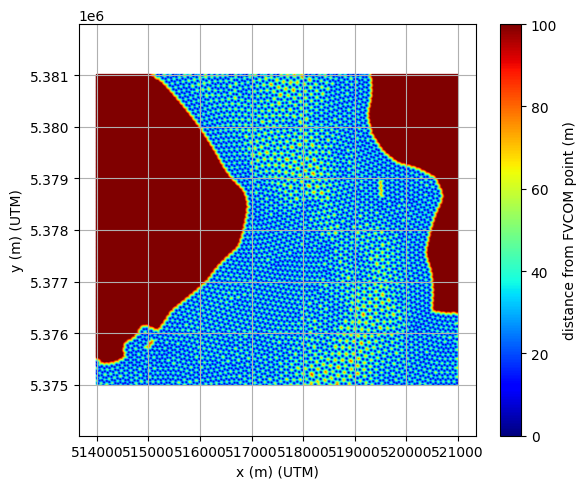

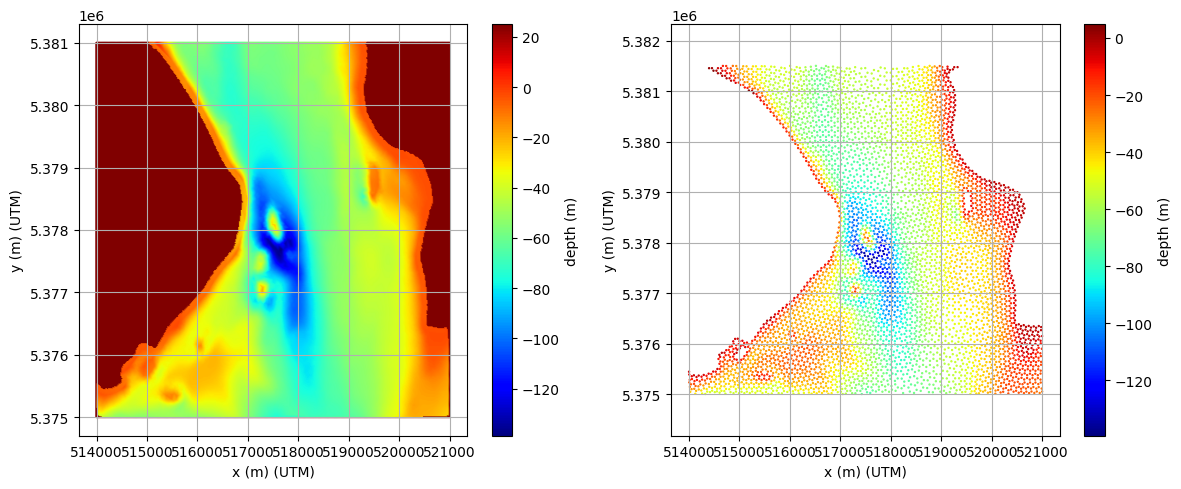

In [5]:
# Get the bathymmetry data.  

# The bathymmetry data is stored in FVCOM's unstructured grid, but we need to get it on a structured grid because the AMR-Wind
# terrain data is structured.

# Define the extents and resolution of the structured data plane.  x,y coordinates are in UTM.  Land is not represented in the FVCOM
# data, so we also need to give a land height.  We will use interpolation to go from the unstructured to structured grid and the
# structured grid of bathymmetry height will include land, so we need to give a land height.  The interpolation by default tries to 
# interpolate the land regions from surrounding known bathymetry depths, and won't return higher than water level values.  So, also
# have to find distance of every structured point from an unstructured point and if that distance is greater than some value (distTol),
# treat it as land and assign it the land height value.

nx = 400
ny = 400
xMin = 514000
xMax = 521000
yMin = 5.375E6
yMax = 5.381E6

landHeight = 25.0
distTol = 100.0




# Form the structured arrays.
xStruct = np.tile(np.linspace(xMin,xMax,nx),ny)
yStruct = np.repeat(np.linspace(yMin,yMax,ny),nx)
hStruct = np.zeros((nx*ny))
distStruct = np.zeros((nx*ny))

# Compute distance of each structured point to nearest unstructured point.
for i in range(nx*ny):
    d = np.sqrt(np.square(xStruct[i] - x) + np.square(yStruct[i] - y))
    distStruct[i] = np.min(d)

# Use scipy's griddata interpolator to interpolate from unstructured depths to structured.
hStruct = sc.interpolate.griddata((x,y),-h,(xStruct,yStruct),method='linear',fill_value=landHeight)


# If a structured point is far enough from an unstructured point, treat it as land.
for i in range(nx*ny):
    if (distStruct[i] > distTol):
        hStruct[i] = landHeight


# Plot the distance values as a check and a way to determine what to set distTol to.
fig,axs = plt.subplots(1,1,figsize=(6,5))
scat = axs.scatter(xStruct,yStruct,c=distStruct,cmap='jet',vmin=0,vmax=100,s=0.5)
plt.axis('equal')
axs.set_xlabel('x (m) (UTM)')
axs.set_ylabel('y (m) (UTM)')
plt.colorbar(scat,label='distance from FVCOM point (m)')
plt.show()



# Plot the structured and unstructed depth data as a check.
fig,axs = plt.subplots(1,2,figsize=(12,5))
scat = axs[0].scatter(xStruct,yStruct,c=hStruct,cmap='jet',s=0.5)
plt.axis('equal')
axs[0].set_xlabel('x (m) (UTM)')
axs[0].set_ylabel('y (m) (UTM)')
plt.colorbar(scat,label='depth (m)')

scat = axs[1].scatter(x,y,c=-h,cmap='jet',s=0.5)
plt.axis('equal')
plt.colorbar(scat,label='depth (m)')
axs[1].set_xlabel('x (m) (UTM)')
axs[1].set_ylabel('y (m) (UTM)')

plt.show()





In [ ]:
# Write the bathymmetry and land height data as an AMR-Wind terrain file.

# Odd interpolation artifacts were happening right at the boundary of structured interpolated data, so for now let's say that the 
# AMR-Wind grid will fit inside the terrain data we have by some buffer distance (buffer).  In other words, if we drew the AMR-Wind
# grid footprint on top of the terrain data, it would be a rectangle inside the terrain data rectangle with an offset of 'buffer'.  

# We also set 0,0 as the location down near the southwest (lower left) corner so that we don't have to make an AMR-Wind grid that
# follows UTM coordinates, but really there is no reason we have to do this.  If you want AMR-Wind's grid to be in UTM coordinates, 
# then just get rid of the '-xMin-buffer' and '-yMin-buffer' You see immediate below.

# Write the AMR-Wind terrain data using Matt's writer function that's in his inflowPrepMMC module.

buffer = 250.0
bathymmetry = mmc.inflowPrepMMC()
bathymmetry.writeAMRWindTerrain(np.transpose(np.reshape(xStruct-xMin-buffer,(nx,ny))),
                                np.transpose(np.reshape(yStruct-yMin-buffer,(nx,ny))),
                                np.transpose(np.reshape(hStruct,(nx,ny))),
                                '/scratch/mchurchf/tidalChannel/rosario/test/terrain.amrwind')





In [ ]:
# Get data on lateral boundaries.

#boundaries = ['xlo','xhi','ylo','yhi']
boundaries = ['ylo']

fields = [
            "velocity",
            "temperature"
         ]
components = [
                3, 
                1
             ]

#  AMR-Wind input file path.  Used so that pyamrex can build the domain and boundaries.
AMRWindInputFile = '/scratch/mchurchf/tidalChannel/rosario/test/rosario.inp'
AMRWindBoundaryDataDirectory = '/scratch/mchurchf/tidalChannel/rosario/test/bndry_files'

#  Overwrite existing AMR-Wind boundary data
AMRWindBoundaryDataOverwrite = True

#  
t = [0.0, 10000.0]



#   Loop over boundaries.
nBoundaries = len(boundaries)
nTimes = len(t)
nFields = len(fields)

for boundary_ in range(nBoundaries):
    print("Processing boundary: " + boundaries[boundary_])

    # Initialize amrex.space3d.
    amr.initialize([])

    # Set the boundary number
    match boundaries[boundary_]:
        case 'xlo':
            orientation = 0
        case 'ylo':
            orientation = 1
        case 'zlo':
            orientation = 2
        case 'xhi':
            orientation = 3
        case 'yhi':
            orientation = 4
        case 'zhi':
            orientation = 5

    
    # Loop over times
    for time_ in range(nTimes):

        # Loop over fields
        for field_ in range(nFields):

            # Set the path to where boundary data files should be written.  Warn if already exists unless the overwrite option is provided.
            bdir = pathlib.Path(AMRWindBoundaryDataDirectory)
            if (bdir.exists() and not AMRWindBoundaryDataOverwrite):
                print('Boundary data already exists')


            # Set the functors used to transfer the data to the AMR-Wind boundary.  Here we use the functor that takes tabular
            # data and piecewise linearly interpolates between given table points.
            fieldFunctor = {}
            vecCompName = ["x","y","z"]
            for comp_ in range(components[field_]):
                if (components[field_] == 3):
                    fieldName = fields[field_] + vecCompName[comp_]
                else:
                    fieldName = fields[field_]
                    
                fieldFunctor[fieldName] = boundaryDataFunctors.Interpolated(coordDir,[coordVals,fieldVals[field_][comp_][time_]])

                
            # Generate the boundary data and write using Marc Henry de Frahan's NativeBoundaryPlane class.
            odir = bdir / f"bndry_output{time_:05d}"
            bp = nbp.NativeBoundaryPlane(fields[field_], components[field_], orientation, odir)
            bp.define_from_file(AMRWindInputFile, time_, t[time_])
            bp.evaluate(fieldFunctor)
            bp.write()


        

    # Finalize amrex.space3d.  If you don't do this and you run this cell again, the kernal crashes.
    amr.finalize()



#   Save the time information.
steps = [i for i in range(nTimes)]
np.savetxt(bdir / "time.dat", np.c_[steps, t], fmt="%.17g")





In [ ]:
iin

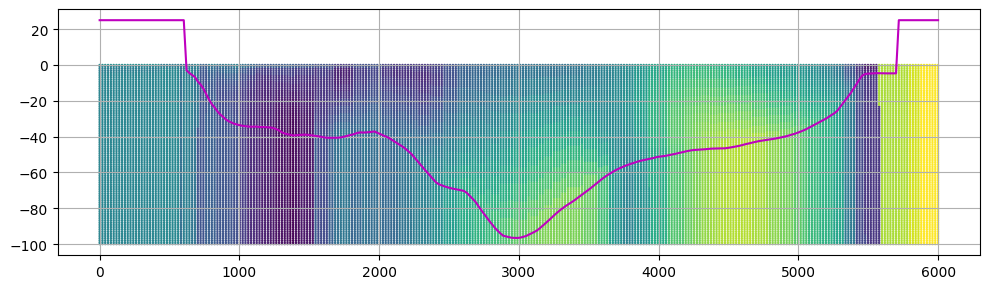

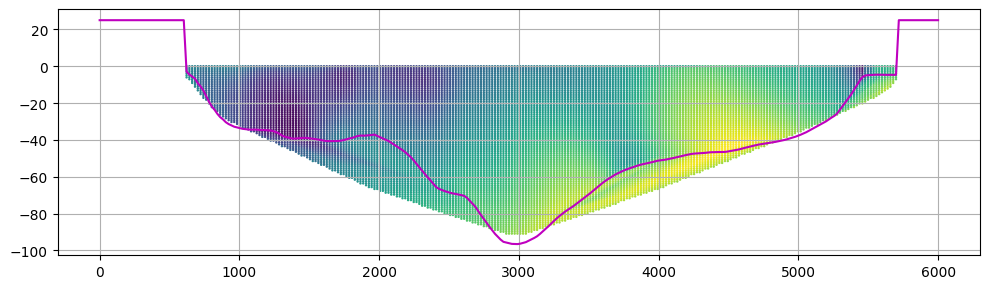

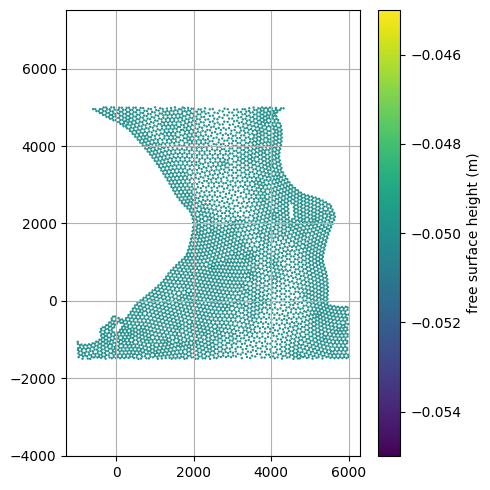

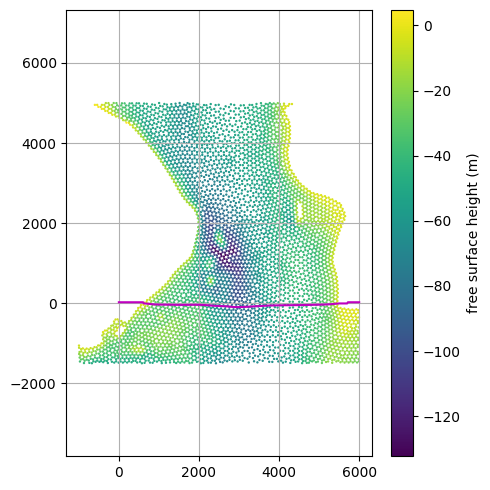

In [75]:

for t in range(len(time)):

    # Set up the x, y, and z variables along with flow variables in a region surrounding the plane we will interpolate to.
    
    # We do not directly have the z-variable as the grid is 2D with sigma-levels that make it 3D.  Water surface height also 
    # varies over time.  z = -depth - (depth + water surface height)*sigma.  Sigma ranges from -1 to 0.
    xin = np.zeros((np.sum(iin),siglay.shape[0]))
    yin = np.zeros((np.sum(iin),siglay.shape[0]))
    zin = np.zeros((np.sum(iin),siglay.shape[0]))
    uin = np.zeros((np.sum(iin),siglay.shape[0]))
    vin = np.zeros((np.sum(iin),siglay.shape[0]))
    
    z = np.zeros((siglay.shape))
    #print(z.shape,h.shape,zeta.shape)
    #print(u.shape)

    # Get the z variable as z = -depth - (depth + water surface height)*sigma.  We loop over the sigma levels.
    for i in range(zin.shape[1]):
        zin[:,i] = -h[iin] - (h[iin]+zeta[t,iin])*siglay[i,iin]

    # Load the x and y variables even though it is repetitive because they don't change over a grid column.
    for i in range(xin.shape[1]):
        xin[:,i] = x[iin]
        yin[:,i] = y[iin]

    # Load the flow variables.
    uin = u[t,:,iin]
    vin = v[t,:,iin]

    # Flatten the variables so we just have an unstructured list.   
    xin = xin.flatten(order='F')
    yin = yin.flatten(order='F')
    zin = zin.flatten(order='F')

    uin = uin.flatten(order='F')
    vin = vin.flatten(order='F')
    

    for i in range(z.shape[0]):
        z[i,:] = -h - (h + zeta[t,:])*siglay[i,:]
    #for i in range(
    #top = sc.interpolate.griddata((x[iin],y[iin]),zeta[t,iin],gridpoints[:,0:2],method='linear')
    #inlet[:,:,t,0] = (np.array(gridpointsXZ[:,2]>bot)*np.array(gridpoints[:,2]<top)*sc.interpolate.griddata((xinterp,yinterp,zin),u[t,:,iin].flatten(order='F'),gridpointsXZ,method='linear',fill_value=0)).reshape((nx,nz),order='F')
    #inlet[:,:,t,1] = (np.array(gridpointsXZ[:,2]>bot)*np.array(gridpoints[:,2]<top)*sc.interpolate.griddata((xinterp,yinterp,zin),v[t,:,iin].flatten(order='F'),gridpointsXZ,method='linear',fill_value=0)).reshape((nx,nz),order='F')
    #top = sc.interpolate.griddata((x[iin],y[iin]),zeta[t,iin],gridpoints[:,0:2],method='nearest')
    #inlet[:,:,t,3] = np.array(gridpointsXZ[:,2]<top).reshape((nh,nv),order='F')

#scat = axs[1].scatter(x,y,c=-h,cmap='jet',s=0.5)
#print(x.shape,y.shape,z.shape,zin.shape,x[iin].shape)

xxx = np.linspace(0,6000,300)
xx,zz = np.meshgrid(np.linspace(0,6000,300),np.linspace(-100,0,100))
yy = np.zeros(np.shape(xx))

interpolatorU_1 = NearestNDInterpolator(list(zip(xin-xyzLoUTM[0], yin-xyzLoUTM[1], zin-xyzLoUTM[2])), vin)
#interpolatorU_1 = LinearNDInterpolator(list(zip(xin-xyzLoUTM[0], yin-xyzLoUTM[1], zin-xyzLoUTM[2])), vin)
interpolatorU_2 = sc.interpolate.griddata((xin-xyzLoUTM[0], yin-xyzLoUTM[1], zin-xyzLoUTM[2]), vin, (xx,yy,zz), method='linear')

interpolator_h = sc.interpolate.griddata((x[iin]-xyzLoUTM[0], y[iin]-xyzLoUTM[1]), -h[iin], (xxx,0), method='linear', fill_value=landHeight)


v1 = interpolatorU_1((xx,yy,zz))
v2 = interpolatorU_2
#x = np.linspace()
#print(interpolatorU_2)

plt.figure(0,figsize=(10,3))
plt.scatter(xx,zz,c=v1,s=0.5)
plt.plot(xxx,interpolator_h,'m-')
#plt.axis('equal')

plt.figure(1,figsize=(10,3))
plt.scatter(xx,zz,c=v2,s=0.5)
plt.plot(xxx,interpolator_h,'m-')
#plt.axis('equal')





plt.figure(10,figsize=(5,5))
plt.scatter(x-xyzLoUTM[0],y-xyzLoUTM[1],c=siglay[0,:],s=0.5)
plt.axis('equal')
plt.colorbar(label='free surface height (m)')

plt.figure(11,figsize=(5,5))
plt.scatter(x-xyzLoUTM[0],y-xyzLoUTM[1],c=z[0,:],s=0.5)
plt.plot(xxx,interpolator_h,'m-')
plt.axis('equal')
plt.colorbar(label='free surface height (m)')

In [40]:
xin-xyzLoUTM[0]

array([3697.71875, 3800.4375 , 3861.59375, ...,  768.53125,  785.125  ,
        846.25   ], shape=(3990,))

In [22]:
## Velocity plane for inlet or outlet

# number of points horizontally and vertically in interpolation plane along with times
nx = 400
nz = 100
nt = ds['time'].shape[0]

# Define the inlet plane variable array which can hold 4 variables.
inlet = np.zeros((nx,nz,nt,4))

# Define the plane geometry to interpolate to.  This is an x-z plane right
gridpointsXZ = np.zeros((nx*nz,3))
gridpointsXZ[:,0] = np.tile(np.linspace(515000,521000,nx),nz)
gridpointsXZ[:,1] = np.tile(np.linspace(inpoint[1],inpoint[1],nx),nz)
gridpointsXZ[:,2] = np.repeat(np.linspace(-np.max(h),10.0,nz),nx)

# This is the subset of FVCOM data to interpolate from.  It is what is highlighted in the plot above.  The variable
# "siglay" is the depth.
xinterp = np.tile(x[iin],siglay.shape[0])
yinterp = np.tile(y[iin],siglay.shape[0])

bot = sc.interpolate.griddata((x[iin],y[iin]),-h[iin],gridpointsXZ[:,0:2],method='linear')


for t in range(len(time)):
    zin = np.zeros((np.sum(iin),siglay.shape[0]))
    for z in range(zin.shape[1]):
        zin[:,z] = -h[iin]-(h[iin]+zeta[t,iin])*siglay[z,iin]
    zin = zin.flatten(order='F')
    top = sc.interpolate.griddata((x[iin],y[iin]),zeta[t,iin],gridpointsXZ[:,0:2],method='linear')
    inlet[:,:,t,0] = (np.array(gridpointsXZ[:,2]>bot)*np.array(gridpointsXZ[:,2]<top)*sc.interpolate.griddata((xinterp,yinterp,zin),u[t,:,iin].flatten(order='F'),gridpointsXZ,method='linear',fill_value=0)).reshape((nx,nz),order='F')
    inlet[:,:,t,1] = (np.array(gridpointsXZ[:,2]>bot)*np.array(gridpointsXZ[:,2]<top)*sc.interpolate.griddata((xinterp,yinterp,zin),v[t,:,iin].flatten(order='F'),gridpointsXZ,method='linear',fill_value=0)).reshape((nx,nz),order='F')
    top = sc.interpolate.griddata((x[iin],y[iin]),zeta[t,iin],gridpointsXZ[:,0:2],method='nearest')
    inlet[:,:,t,3] = np.array(gridpointsXZ[:,2]<top).reshape((nx,nz),order='F')



TypeError: only integer scalar arrays can be converted to a scalar index

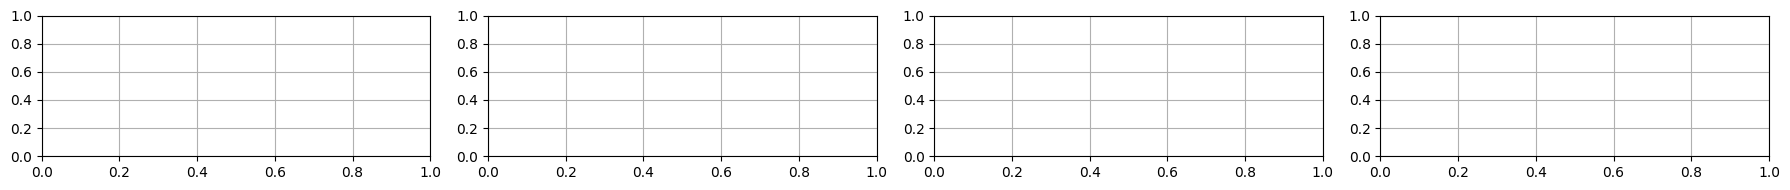

In [24]:
for t in [86,92,100,105]:
    fig,axs = plt.subplots(1,4,figsize=(18,2))
    for dir in range(4):
        im = axs[dir].pcolormesh(range(nx),np.linspace(-np.max(h),10.0,nv),np.transpose(inlet[:,:,t,dir]),vmin=-1,vmax=1,cmap='RdBu_r',shading='nearest')
        plt.colorbar(im,ax=axs[dir],label=['u [m/s]','v [m/s]','w [m/s]','vof [-]'][dir])
        axs[dir].set(xlabel='iH',ylabel='Z [m]')
    plt.show()

In [ ]:
## Pick time step to use (

sig = 0
fig,axs = plt.subplots(1,1,figsize=(11,2))
axs.plot(time,(u[:,sig,ifast]**2+v[:,sig,ifast]**2)**0.5)
#axs.plot(time,np.mean(v[:,sig,iin],1))
for t in [87]:
    axs.axvline(time[t],c='r')
plt.show()

In [ ]:
## Save netcdf file for selected time step (only 1 time since FVCOM dt is 30 minutes)

t = 87

if os.path.exists(savepath+'inlet.nc'): os.remove(savepath+'inlet.nc')
with nc.Dataset(savepath+'inlet.nc', 'w', format='NETCDF4') as inletnc:
    inletnc.description = 'Inlet Boundary'
    inletnc.createDimension('ncell',nh*nv)
    xnc = inletnc.createVariable('x','f4',('ncell',))
    ync = inletnc.createVariable('y','f4',('ncell',))
    znc = inletnc.createVariable('z','f4',('ncell',))
    unc = inletnc.createVariable('u','f4',('ncell',))
    vnc = inletnc.createVariable('v','f4',('ncell',))
    wnc = inletnc.createVariable('w','f4',('ncell',))
    vofnc = inletnc.createVariable('vof','f4',('ncell',))
    xnc.units = 'm'
    ync.units = 'm'
    znc.units = 'm'
    unc.units = 'm/s'
    vnc.units = 'm/s'
    wnc.units = 'm/s'
    vofnc.units = '-'
    xnc[:] = gridpoints[:,0]
    ync[:] = gridpoints[:,1]
    znc[:] = gridpoints[:,2]
    unc[:] = inlet[:,:,t,0].flatten(order='F')
    vnc[:] = inlet[:,:,t,1].flatten(order='F')
    wnc[:] = inlet[:,:,t,2].flatten(order='F')
    vofnc[:] = inlet[:,:,t,3].flatten(order='F')

In [ ]:
## Build channel file

nx = 100
ny = 100
xbath = np.linspace(np.min(x),np.max(x),nx)
ybath = np.linspace(np.min(y),np.max(y),ny)
zbath = np.zeros((nx*ny))

bath = np.zeros((2+nx+ny+nx*ny))
bath[0] = nx
bath[1] = ny
bath[2:2+nx] = xbath
bath[2+nx:2+nx+ny] = ybath

xyinterp = np.array([x,y]).T

for iy in range(ny):
    yy = ybath[iy]
    zrow = sc.interpolate.griddata(xyinterp,-h,np.array([xbath,np.ones(ny)*yy]).T,method='nearest')
    for ix in range(nx):
        xx = xbath[ix]
        zz = zrow[ix]
        zbath[ix*ny+iy] = zz
        bath[2+nx+ny+ix*ny+iy] = zz
np.savetxt(savepath+'channel.amrwind',bath,fmt='%.2f')

fig,axs = plt.subplots(1,2,figsize=(18,6))
im = axs[0].scatter(x,y,c=-h,cmap='jet',s=1)
plt.colorbar(im,ax=axs[0],label='Depth [m]')
im = axs[1].scatter(np.repeat(xbath,ny),np.tile(ybath,nx),c=zbath,cmap='jet',s=0.5)
plt.colorbar(im,ax=axs[1],label='Depth [m]')
plt.show()

plt.figure(1,figsize=(7,6))
im = plt.scatter((x/1000)-514,(y/1000)-5375,c=-h,cmap='jet',s=1)
plt.colorbar(im,label='Depth [m]')
plt.xlabel('x (km)')
plt.ylabel('y (km)')

## Old test case

In [ ]:
ex = np.loadtxt('/home/pwiley/AMRWind/amr-wind/test/test_files/terrain_box/terrain.amrwind')
nx = int(ex[0])
ny = int(ex[1])

x = ex[2:2+nx]
y = ex[2+nx:2+nx+ny]
z = ex[2+nx+ny:]

In [ ]:
fig = plt.figure(figsize=(6,6)); axs = plt.axes(projection ='3d');
for ix in range(nx):
    axs.scatter(x[ix]*np.ones(ny),y,z[ix*ny:ix*ny+ny])
axs.set(xlabel='x',ylabel='y')
plt.show()

In [ ]:
## Build channel file

xmin = 0.0
xmax = 100.0
ymin = -25.0
ymax = 25.0

zmin = -25.0

zside = -10.0
yslope = 10.0

nx = 64
ny = 32

x = np.linspace(xmin,xmax,nx)
y = np.linspace(ymin,ymax,ny)
z = np.zeros((nx*ny))

chan = np.zeros((2+nx+ny+nx*ny))
chan[0] = nx
chan[1] = ny
chan[2:2+nx] = x
chan[2+nx:2+nx+ny] = y

for iy in range(ny):
    yy = y[iy]
    for ix in range(nx):
        xx = x[ix]
        if np.abs(yy) > yslope:
            zz = (np.abs(yy)-yslope)/(ymax-yslope)*(zside-zmin) + zmin
        else:
            zz = zmin
        z[ix*ny+iy] = zz
        chan[2+nx+ny+ix*ny+iy] = zz

np.savetxt('/scratch/pwiley/Resource/AMRWind/ow_current_bathymetry/channel.amrwind',chan,fmt='%.2f')

fig = plt.figure(figsize=(6,6)); axs = plt.axes(projection ='3d');
for ix in range(nx):
    axs.scatter(x[ix],y*np.ones(ny),z[ix*ny:ix*ny+ny])
axs.set(xlabel='x',ylabel='y')
plt.show()